In [41]:
import os
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
# CONSTANTS
# CONSTANTS
plt.style.use('dark_background')

EXAMPLES_FOR_PLOT = 5
LATENT_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 100
DEVICE = "cpu"

if torch.cuda.is_available():
    DEVICE = "cuda"

LOCAL_DATA_PATH = ".local_data"
DATASET_PATH = f"{LOCAL_DATA_PATH}/datasets"
WEIGHTS_PATH = f"{LOCAL_DATA_PATH}/model_weights"
LOGS_PATH = f"{LOCAL_DATA_PATH}/logs"
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(WEIGHTS_PATH, exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)

# DATA PREP

os.makedirs(DATASET_PATH, exist_ok=True)
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.Normalize((0.1307,), (0.3081,)) TODO investigate
])
train_data = torchvision.datasets.MNIST(DATASET_PATH, download=True, transform=transform, train=True)
test_data = torchvision.datasets.MNIST(DATASET_PATH, download=True, transform=transform, train=False)

train_dataloader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, BATCH_SIZE, shuffle=False)

# getting EXAMPLES_FOR_PLOT examples for plotting, TODO rewrite
examples = None
for X, _ in test_dataloader:
    examples = X[:EXAMPLES_FOR_PLOT, :].to(DEVICE)
    break

# MODEL TODO separate file
import torch
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(inplace=True),
        )

        self.mu_head = nn.Linear(256, latent_dim)
        self.std_head = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (128, 7, 7)),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.Sigmoid(),
        )

    def encode(self, x):
        """Encode input into mean and standard deviation."""
        h = self.encoder(x)
        mu = self.mu_head(h)
        std = self.std_head(h)
        return mu, std

    def reparameterize(self, mu, std):
        """Reparameterization trick: sample z = mu + std * eps."""
        eps = torch.randn_like(std)          # device‑agnostic, same shape as std
        return mu + eps * std

    def decode(self, z):
        """Decode latent vector into reconstructed image."""
        return self.decoder(z)

    def forward(self, x):
        mu, std = self.encode(x)
        z = self.reparameterize(mu, std)
        recon = self.decode(z)
        return recon, mu, std

class ELBOLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y, y_prim, mu, std):
        # kl = torch.mean(-0.5 * torch.sum(1 + torch.log(std**2) - mu**2 - std**2, dim=1))

        mse_loss = F.mse_loss(y, y_prim)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + std - mu ** 2 - std.exp(), dim=1), dim=0)
        kld_weight = 1

        # kld_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mu ** 2 - log_var.exp(), dim = 1), dim = 0)

        loss = mse_loss + kld_weight * kld_loss
        return mse_loss, kld_loss

model = VAE(LATENT_SIZE)
model.load_state_dict(torch.load(f"{WEIGHTS_PATH}/vae_mnist.pt", weights_only=True))
model.eval()

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=3136, out_features=256, bias=True)
    (6): ReLU(inplace=True)
  )
  (mu_head): Linear(in_features=256, out_features=64, bias=True)
  (std_head): Linear(in_features=256, out_features=64, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=6272, bias=True)
    (1): ReLU(inplace=True)
    (2): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Sigmoid()
  )
)

In [42]:
examples_for_generation = defaultdict(list)
for idx, (_, y) in enumerate(test_data):
    examples_for_generation[y].append(idx)
    if idx >= 500:
        break

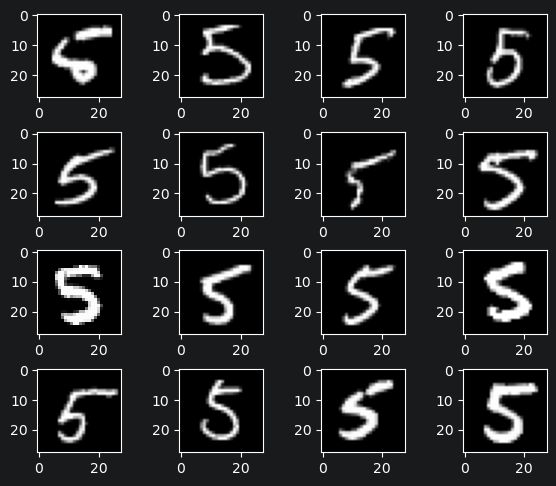

In [57]:
# generating number 1
numbers = examples_for_generation[5]
x_to_encode = []
for idx in numbers[:16]:
    x_to_encode.append(test_data[idx][0])

plt_rows = int(np.ceil(np.sqrt(len(x_to_encode))))
for i in range(len(x_to_encode)):
    plt.subplot(plt_rows, plt_rows, i + 1)
    x = x_to_encode[i]
    plt.imshow(x.squeeze(), cmap="gray")
    plt.tight_layout(pad=0.5)
plt.show()

100%|██████████| 16/16 [00:01<00:00, 12.93it/s]


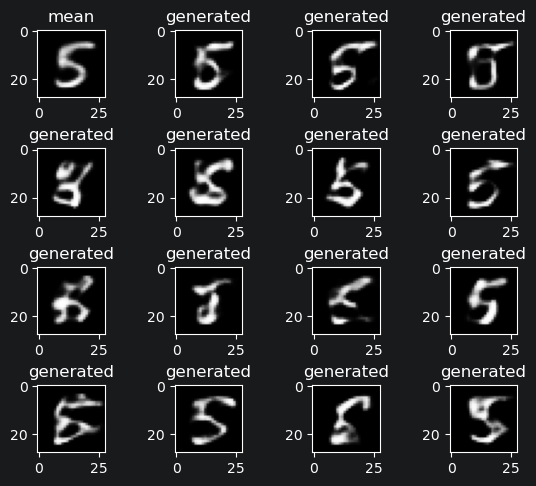

In [58]:
GENERATE_COUNT = 16

x_tensor = torch.stack(x_to_encode)
z_mu, z_std = model.encode(x_tensor)
zs = model.reparameterize(z_mu, z_std)
z_mu = torch.mean(zs, dim=0)
z_sigma = torch.std(zs, dim=0)

# sample new letters
z_generated = []
dist = torch.distributions.Normal(z_mu, z_sigma)
for i in range(GENERATE_COUNT):
    if i == 0:
        z = z_mu
    else:
        z = dist.sample()
    z_generated.append(z)
z = torch.stack(z_generated)

x_generated = model.decode(z).permute(0, 2, 3, 1)

plt_rows = int(np.ceil(np.sqrt(GENERATE_COUNT)))
for i in tqdm(range(GENERATE_COUNT)):
    plt.subplot(plt_rows, plt_rows, i + 1)
    plt.imshow(x_generated[i].cpu().squeeze().detach().numpy(), cmap="gray")
    if i == 0:
        plt.title(f"mean")
    else:
        plt.title(f"generated")
    plt.tight_layout(pad=0.5)
plt.show()